In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

plt.style.use('sci.mplstyle')

In [27]:
def khoitao_u(dt, dx, tmax, L,f_x, g_x):
    n = int(tmax / dt) + 1   # n la thoi gian
    m = int(L / dx) + 1   # m la khong gian

    u = np.zeros((n, m))
    x = np.linspace(0, L, m)
    t = np.linspace(0, tmax, n)

    # Dieu kien dau theo thoi gian: u(0,x) = f(x), 
    for j in range(m):
        u[0, j] = f_x(x[j], L)
        u[1, j] = u[0, j] + dt * g_x(x[j], L)


    # Dieu kien theo khong gian tai moi thoi diem: u(0,t) = u(L,t) = 0
    u[:, 0] = 0.0
    u[:, -1] = 0.0

    return u, x, t

def tinh_beta(c,k,h):
    beta  = c * k / h
    if beta > 1:
        print("Canh bao: beta =", beta, " > 1. Phuong phap co the khong on dinh.")
        ondinh = False
    else:
        ondinh = True
        print("Gia tri beta =", beta, " <= 1. Phuong phap on dinh.")
        return beta, ondinh

In [28]:
def ghifile(u, x, t, beta, filename):
    filename = f"{filename}_beta_{beta:.2f}.txt"
    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"# Bai toan truyen song 1D \n")
        file.write("# Phuong phap sai phan huu han hien\n")
        file.write("#\n")
        file.write(f"# N_x    = {x.shape[0]}\n")
        file.write(f"# N_time = {t.shape[0]}\n")
        file.write(f"# l      = {x[-1]}\n")
        file.write(f"# t_max  = {t[-1]}\n")
        file.write("#\n")
        file.write(f"# {'t_step':>10s} {'x_step':>10s} {'t':>15s} {'x':>15s} {'u':>15s}\n")

        for t_step in range(t.shape[0]):
            for x_step in range(x.shape[0]):
                file.write(f"  {t_step:10d} {x_step:10d} {t[t_step]:15.8e} {x[x_step]:15.8e} {u[t_step, x_step]:15.8e}\n")
            file.write("\n\n")

In [29]:
def ham_forward_khong_friction(c,k,h, tmax, L, f_x, g_x, filename):
    u, x ,t  = khoitao_u(k, h, tmax, L, f_x, g_x)
    n,m = u.shape
    beta, ondinh = tinh_beta(c, k, h)
    if ondinh == True:
        for i in range(1,n-1): # n la thoi gian
            for j in range(1,m-1): #  m la khong gian
                u[i+1,j] = 2*(1-beta**2)*u[i,j] + beta**2*(u[i,j+1]+u[i,j-1]) - u[i-1,j]
        ghifile(u, x, t, beta, filename)
    else:
        print("Phuong phap khong on dinh, khong the tinh toan.")
    return

## Bai 1 (khong friction)

In [30]:
## Ham bai 1
def f_x_bai1(x, l):
    if x <= 0.8*l:
        return 1.25*x/l
    else:
        return 5 - 5*x/l

## Van toc bai 1
def g_x_bai1(x, l):
    g_x  = 0
    return g_x

In [31]:
T = 40
rho = 0.01

c = np.sqrt(T/rho)  # Van toc song
print ("Van toc song c =", c)

L               = 1.0           # Chieu dai day
t_max           = 0.1           # Thoi gian mo phong
delta_x         = 0.007          # Buoc khong gian
delta_t         = 0.0001        # Buoc thoi gian  

beta_estimate = c * delta_t / delta_x
print("Beta du kien =", beta_estimate)

Van toc song c = 63.245553203367585
Beta du kien = 0.9035079029052513


In [32]:
ham_forward_khong_friction(c=c, k=delta_t, h=delta_x, tmax=t_max, L=L, f_x=f_x_bai1, g_x=g_x_bai1, filename="ketqua_bai1")

Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.


In [33]:
t_063, x_063, u_063 = np.loadtxt("ketqua_bai1_beta_0.63.txt", comments='#', unpack=True, usecols=(2, 3, 4))
t_090, x_090, u_090 = np.loadtxt("ketqua_bai1_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))

In [34]:
def ve_3d(t_flat, x_flat, u_flat, beta, ax, cmap='coolwarm', vmin=None, vmax=None):
    x_vals = np.unique(x_flat)
    t_vals = np.unique(t_flat)
    nx = len(x_vals)
    nt = len(t_vals)

    T = t_flat.reshape(nt, nx)
    X = x_flat.reshape(nt, nx)
    U = u_flat.reshape(nt, nx)

    surf = ax.plot_surface(T, X, U, cmap=cmap, alpha=0.85, vmin=vmin, vmax=vmax)
    ax.set_xlabel('Thoi gian t (s)', labelpad=20)
    ax.set_ylabel('Vi tri x (m)', labelpad=20)
    ax.set_zlabel('Bien do u (m)', labelpad=20)
    return surf

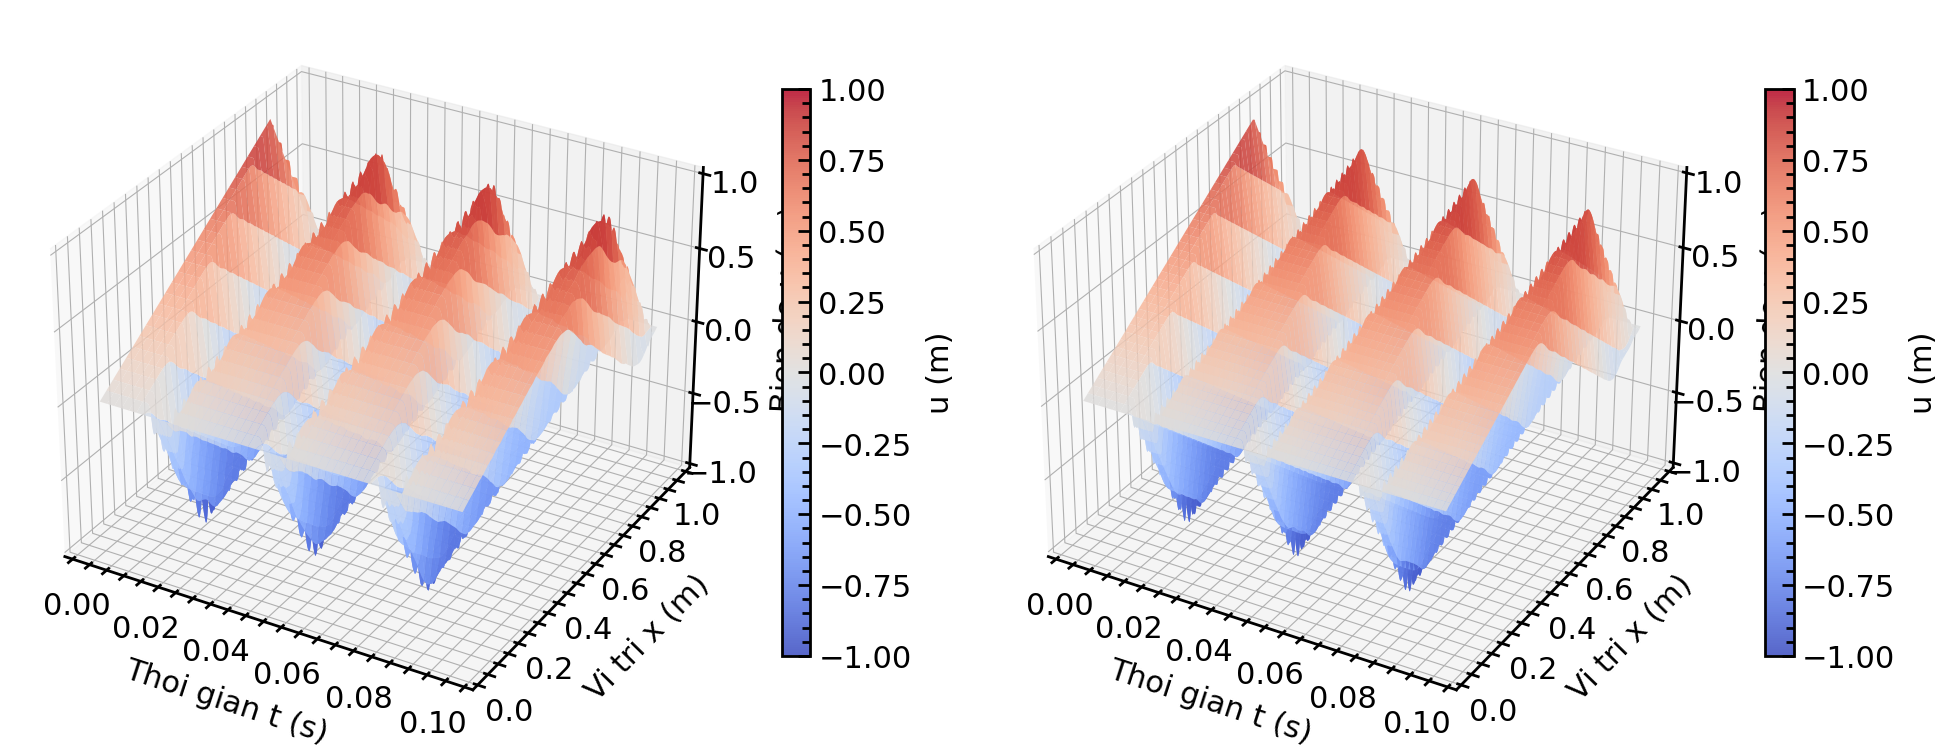

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(20, 12))

surf1 = ve_3d(t_063, x_063, u_063, beta=0.63, ax=ax1, cmap='coolwarm', vmin=-1, vmax=1)
surf2 = ve_3d(t_090, x_090, u_090, beta=0.90, ax=ax2, cmap='coolwarm', vmin=-1, vmax=1)

fig.colorbar(surf1, ax=ax1, shrink=0.5, label='u (m)')
fig.colorbar(surf2, ax=ax2, shrink=0.5, label='u (m)')

plt.tight_layout()
plt.savefig("wave_3d.pdf")
plt.show()

## Bai 1 (Ham sin)


In [36]:
def f_x_bai1_ham_sin(x, l):
    return np.sin(x * np.pi / l)
def g_x_bai1_ham_sin(x, l):
    return 0

In [37]:
ham_forward_khong_friction(c=c, k=delta_t, h=delta_x, tmax=t_max, L=L, f_x=f_x_bai1_ham_sin, g_x=g_x_bai1_ham_sin, filename="ketqua_bai1_hamsin")

Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.


In [38]:
t_sin, x_sin, u_sin = np.loadtxt("ketqua_bai1_hamsin_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))

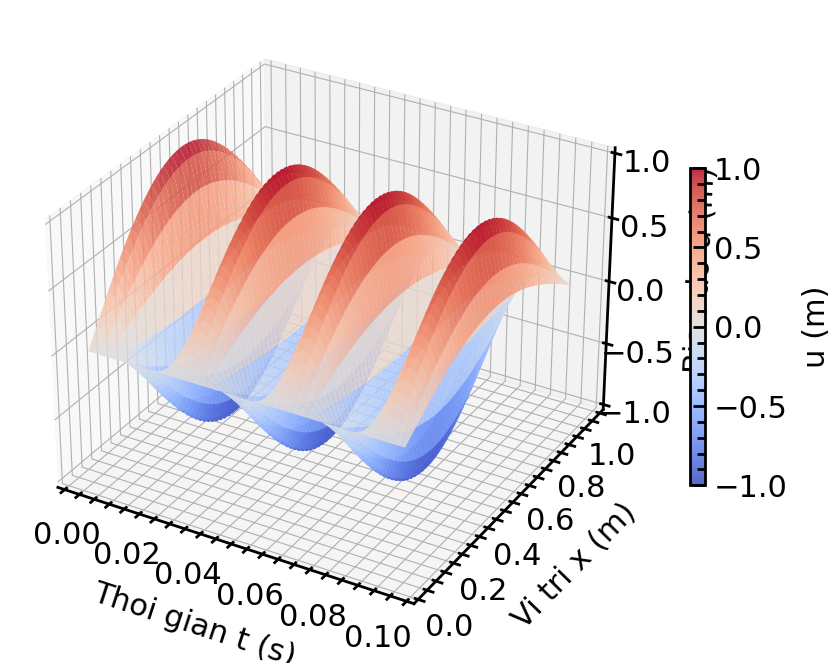

In [39]:
fig, ax1 = plt.subplots(1, 1, subplot_kw={'projection': '3d'}, figsize=(10, 7))

surf1 = ve_3d(t_sin, x_sin, u_sin, beta=0.90, ax=ax1, cmap='coolwarm', vmin=-1, vmax=1)

fig.colorbar(surf1, ax=ax1, shrink=0.5, label='u (m)')

plt.tight_layout()
plt.savefig("wave_3d_sin.pdf")
plt.show()

## Bai 1 (co friction)

In [40]:
def ham_forward_friction(c, k, h, tmax, L, f_x, g_x, kappa, rho, filename):
    u, x, t = khoitao_u(k, h, tmax, L, f_x, g_x)
    n, m = u.shape

    beta, ondinh = tinh_beta(c, k, h)
    gamma = 2 * kappa * k / rho

    if ondinh:
        for i in range(1, n - 1):
            for j in range(1, m - 1):
                lap = u[i, j+1] - 2*u[i, j] + u[i, j-1]
                u[i+1, j] = (2-gamma)*u[i,j] + (gamma-1)*u[i-1,j] + beta**2*lap
        ghifile(u, x, t, beta, filename)
    else:
        print("Phuong phap khong on dinh, khong the tinh toan.")

    return u, x, t

In [41]:
kappa = [0.01, 1, 2, 5, 10]

for i in kappa:
    ham_forward_friction(c=c, k=delta_t, h=delta_x, tmax=t_max, L=L, f_x=f_x_bai1, g_x=g_x_bai1, kappa=i, rho=rho, filename=f"ketqua_bai1_co_friction_kappa_{i}")

Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.
Gia tri beta = 0.9035079029052513  <= 1. Phuong phap on dinh.


In [42]:
t_kappa_001, x_kappa_001, u_kappa_001 = np.loadtxt("ketqua_bai1_co_friction_kappa_0.01_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))
t_kappa_1, x_kappa_1, u_kappa_1 = np.loadtxt("ketqua_bai1_co_friction_kappa_1_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))
t_kappa_2, x_kappa_2, u_kappa_2 = np.loadtxt("ketqua_bai1_co_friction_kappa_2_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))
t_kappa_5, x_kappa_5, u_kappa_5 = np.loadtxt("ketqua_bai1_co_friction_kappa_5_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))
t_kappa_10, x_kappa_10, u_kappa_10 = np.loadtxt("ketqua_bai1_co_friction_kappa_10_beta_0.90.txt", comments='#', unpack=True, usecols=(2, 3, 4))

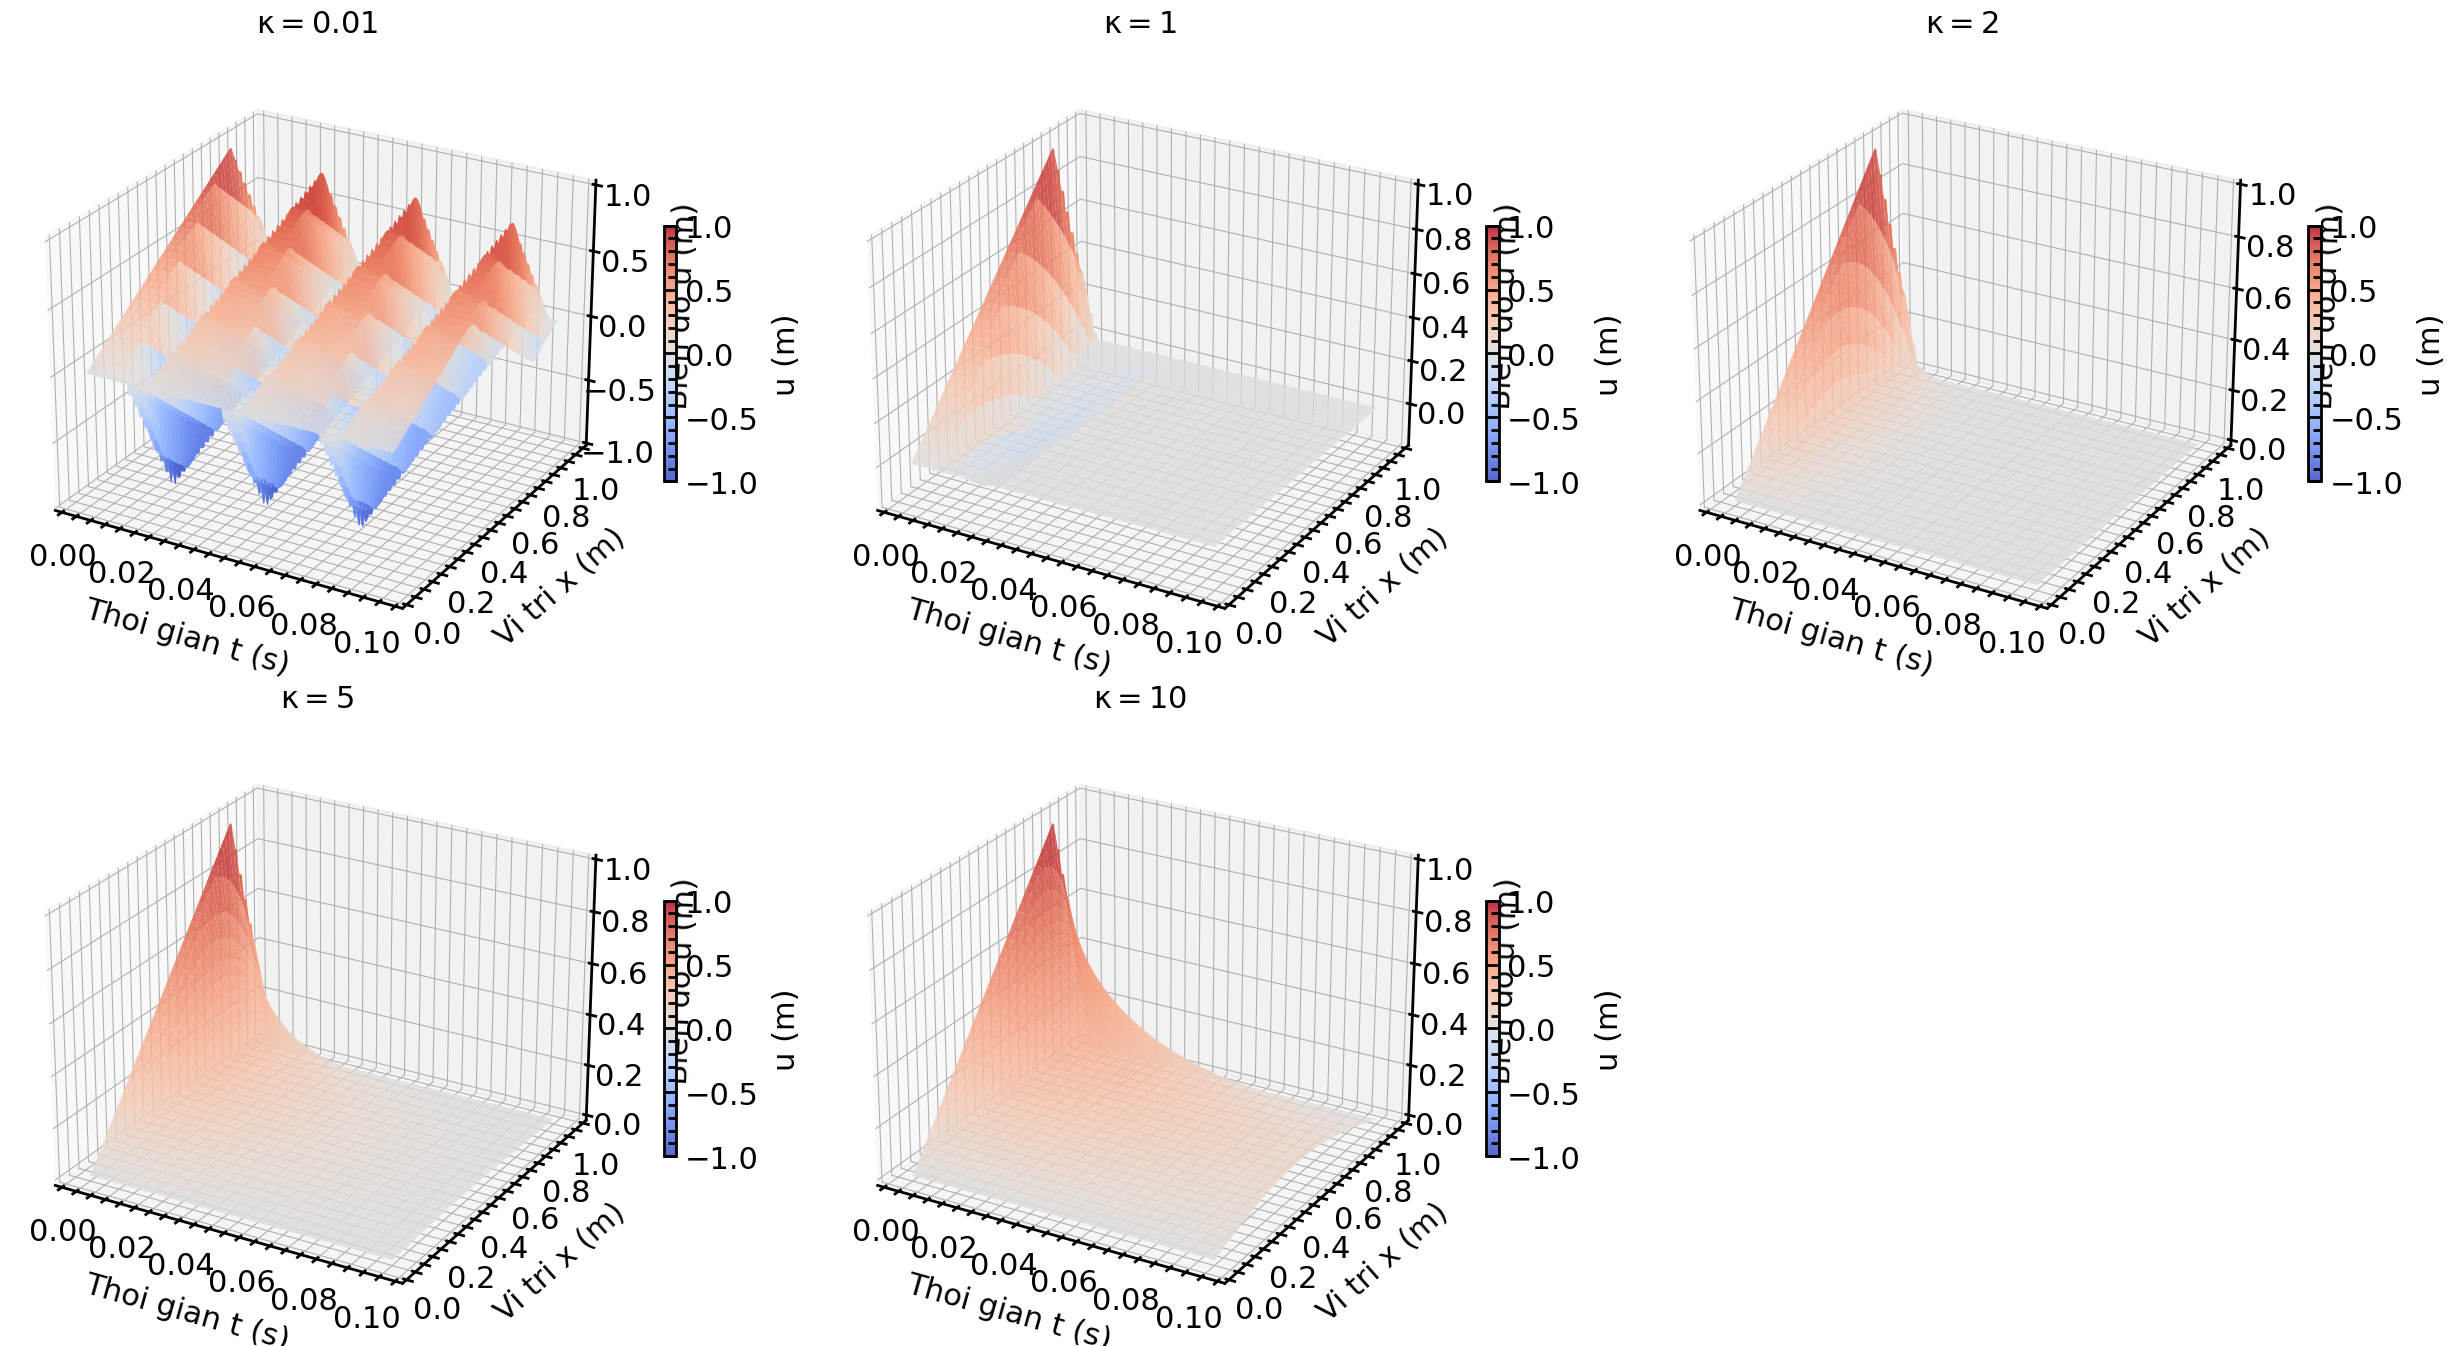

In [43]:
fig, axes = plt.subplots(2, 3, subplot_kw={'projection': '3d'}, figsize=(25, 14))
datasets = [
    (t_kappa_001, x_kappa_001, u_kappa_001, r'$\kappa = 0.01$'),
    (t_kappa_1,   x_kappa_1,   u_kappa_1,   r'$\kappa = 1$'),
    (t_kappa_2,   x_kappa_2,   u_kappa_2,   r'$\kappa = 2$'),
    (t_kappa_5,   x_kappa_5,   u_kappa_5,   r'$\kappa = 5$'),
    (t_kappa_10,  x_kappa_10,  u_kappa_10,  r'$\kappa = 10$'),
]
axes_flat = axes.flatten()
for i, (t, x, u, title) in enumerate(datasets):
    ax = axes_flat[i]
    surf = ve_3d(t, x, u, beta=0.90, ax=ax, cmap='coolwarm', vmin=-1, vmax=1)
    ax.view_init(elev=25, azim=-60)
    ax.set_title(title)
    fig.colorbar(surf, ax=ax, shrink=0.4, label='u (m)',
                 norm=mcolors.Normalize(vmin=-1, vmax=1))
axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig("wave_all_kappa.pdf", bbox_inches='tight')
plt.show()

## Thuc hanh 2

3. Compare the analytic and numeric solutions, summing at least 200 terms in the analytic solution.
4. Use the plotted time dependence to estimate the peak’s propagation velocity c. Compare the deduced c to (21.4).
5. Our solution of the wave equation for a plucked string leads to the formation of a wave packet that corresponds to the sum of multiple normal modes of
the string. On the right in Figure 21.3 we show the motion resulting from the
string initially placed in a single normal mode (standing wave), but with friction (to be discussed soon) included. Modify your program to incorporate this initial condition and see if a normal mode results.
6. Observe the motion of the wave for initial conditions corresponding to the sum of two adjacent normal modes. Does beating occur?
7. When a string is plucked near its end, a pulse reﬂects oﬀ the ends and bounces back and forth. Change the initial conditions of the model program to one corresponding to a string plucked exactly in its middle and see if a traveling  or a standing wave results.
8. Figure 21.4 shows the wave packets that result as a function of time for initial  conditions corresponding to the double pluck. Verify that initial conditions of  the form

Nghiem giai tich cua bai toan day hai dau co dinh co the duoc bieu dien duoi dang chuoi Fourier sin:

$$u(x,t) = \sum_{n=1}^{\infty} B_n \sin\left(\frac{n\pi x}{L}\right) \cos\left(\frac{cn\pi t}{L}\right) \tag{32}$$

Trong do, voi dieu kien dau dang xet, cac he so Fourier duoc cho boi

$$B_n = \frac{12.5 \sin(0.8n\pi)}{n^2\pi^2} \tag{33}$$

In [44]:
# Dung 200 terms cho tong
def nghiem_giai_tich(x,t,L):
    u = 0
    for n in range(1,200):
        B_n =  12.5*np.sin(np.pi*n*0.8)/(n*np.pi)**2
        u += B_n * np.sin(n*np.pi*x/L) * np.cos(c*n*np.pi*t/L)
    return u

In [45]:
def sosanh(filename):
    
    t_step, x_step, t_num, x_num, u_num = np.loadtxt(filename, comments='#', unpack=True, usecols=(0,1, 2, 3, 4))

    t_max_step = int(np.max(t_step))
    x_max_step = int(np.max(x_step))

    u_analytical = nghiem_giai_tich(x_num, t_num, L)

    delta_u = np.abs(u_num - u_analytical)

    max_error = np.max(delta_u)
    print(f"Sai so lon nhat: {max_error:.6e}")

    t_num_2d = t_num.reshape(t_max_step + 1, x_max_step + 1)
    x_num_2d = x_num.reshape(t_max_step + 1, x_max_step + 1)
    u_analytical_2d = u_analytical.reshape(t_max_step + 1, x_max_step + 1)
    delta_u_2d = delta_u.reshape(t_max_step + 1, x_max_step + 1)
    u_num_2d = u_num.reshape(t_max_step + 1, x_max_step + 1)

    filename_compare = f"{filename}_comparison"
    with open(filename_compare, "w", encoding="utf-8") as file:
        file.write(f"# Bai toan truyen song 1D \n")
        file.write("# Phuong phap sai phan huu han hien\n")
        file.write("#\n")
        file.write(f"# N_x    = {x.shape[0]}\n")
        file.write(f"# N_time = {t.shape[0]}\n")
        file.write(f"# l      = {x[-1]}\n")
        file.write(f"# t_max  = {t[-1]}\n")
        file.write(f"# max_error = {max_error:.6e}\n")
        file.write("#\n")
        file.write(f"# {'t_step':>10s} {'x_step':>10s} {'t':>15s} {'x':>15s} {'u_num':>15s} {'u_analytical':>15s} {'delta_u':>15s}\n")

        for t_step_i in range(t_max_step + 1):
            for x_step_i in range(x_max_step + 1):
                file.write(f"  {t_step_i:10d} {x_step_i:10d} {t_num_2d[t_step_i, x_step_i]:15.8e} {x_num_2d[t_step_i, x_step_i]:15.8e} {u_num_2d[t_step_i, x_step_i]:15.8e} {u_analytical_2d[t_step_i, x_step_i]:15.8e} {delta_u_2d[t_step_i, x_step_i]:15.8e}\n")
            file.write("\n\n")

In [46]:
sosanh("ketqua_bai1_beta_0.90.txt")

Sai so lon nhat: 1.170839e-01


In [48]:
t_step_plot = [0, 200, 250, 300, 400, 500]

filename = "ketqua_bai1_beta_0.90.txt_comparison"
t_step, x_step, t_num, x_num, u_num, u_anal, delta = np.loadtxt(filename, comments='#', unpack=True)

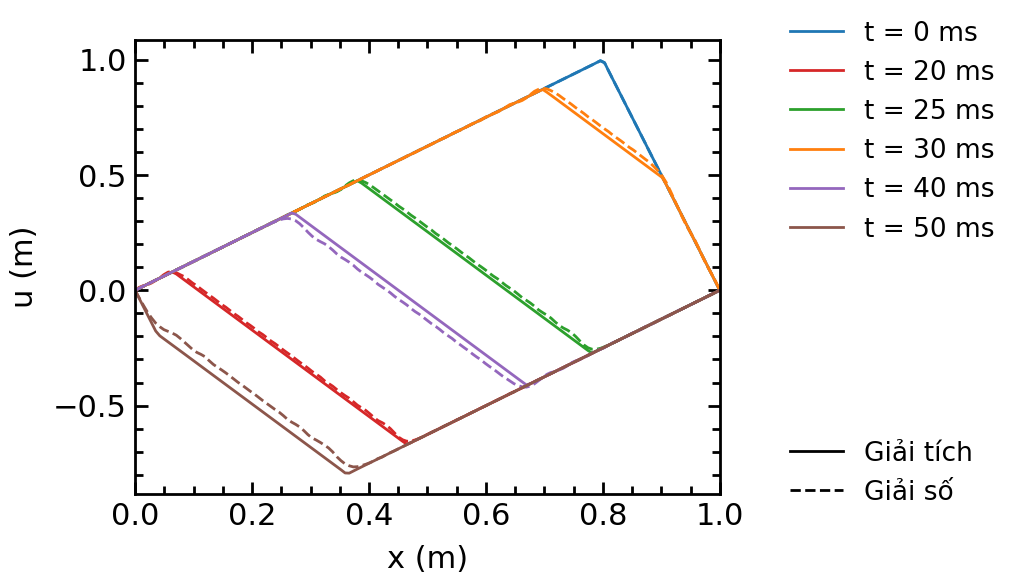

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, ts in enumerate(t_step_plot):
    mask   = (t_step == ts)
    x_plot = x_num[mask]
    t_val  = t_num[mask][0]
    ax.plot(x_plot, u_anal[mask], '-',  color=f"C{i}")
    ax.plot(x_plot, u_num[mask],  '--', color=f"C{i}")

ax.set_xlabel('x (m)')
ax.set_ylabel('u (m)')
ax.set_xlim(0, L)

time_handles = [
    Line2D([0], [0], color=f"C{i}", ls='-',
           label=f't = {t_num[t_step == ts][0]*1000:.0f} ms')
    for i, ts in enumerate(t_step_plot)
]

method_handles = [
    Line2D([0], [0], color='k', ls='-',  label='Giải tích'),
    Line2D([0], [0], color='k', ls='--', label='Giải số'),
]

fig.legend(handles=time_handles,   bbox_to_anchor=(1.0, 1.0), loc='upper left', borderaxespad=0.1)
fig.legend(handles=method_handles, bbox_to_anchor=(1.0, 0.3), loc='upper left', borderaxespad=0.1)

plt.tight_layout()
plt.savefig("hinh_dang_soi_day.pdf", bbox_inches='tight')
plt.show()

In [56]:
# Gio can ly vi tri cua dinh song
#np.unique(t_step)
#mask = (t_step == 250)

buocthoigian_khacnhau = np.unique(t_step)

peaks = []


for time_step_quantam in buocthoigian_khacnhau:
    mask = (t_step == time_step_quantam)

    # Day la mang x tai muc thoi gian quan tam
    x_num_tai_mang_time_quantam = x_num[mask]
    # Day la mang u tai muc thoi gian quan tam. Kieu nay giong nhu la co rat nhieu so giong nhau 0000 1111 2222
    # Thi thang nay chi quan tam den 1111 hay 2222 gi do
    # Khong quan tam den may so ngoai vong lap
    u_num_tai_mang_time_quantam = u_num[mask]
    u_anal_tai_mang_time_quantam = u_anal[mask]

    # argmax la tra ve chi so cua phan tu lon nhat
    u_max_num_id = np.argmax(np.abs(u_num_tai_mang_time_quantam))
    u_max_anal_id = np.argmax(np.abs(u_anal_tai_mang_time_quantam))

    # lay cac gia tri tuong ung voi chi so vua tim duoc
    u_max_num = u_num_tai_mang_time_quantam[u_max_num_id]
    u_max_anal = u_anal_tai_mang_time_quantam[u_max_anal_id]
    x_step_chua_u_num = x_num_tai_mang_time_quantam[u_max_num_id]
    x_step_chua_u_anal = x_num_tai_mang_time_quantam[u_max_anal_id] #do cai x_num chia nhu nhau


    #t_step = [0,   0,   0,   1,   1,   1  ]
    #t_num  = [0.0, 0.0, 0.0, 0.001, 0.001, 0.001]
    #mask (ts=1) = [F, F, F, T, T, T]
    #t_num[mask] = [0.001, 0.001, 0.001]

    t_max = t_num[mask][0] #lay gia tri thoi
    peaks.append((t_max, x_step_chua_u_num, u_max_num, x_step_chua_u_anal, u_max_anal))

    filename_vantoc = "ketqua_bai2_beta_0.90_peaks_compare.txt"

    with open(filename_vantoc, "w", encoding="utf-8") as file:
        file.write(f"# Bai toan truyen song 1D \n")
        file.write("# Phuong phap sai phan huu han hien\n")
        file.write("# Ghi lai vi tri va bien do cua dinh song tai moi thoi diem\n")
        file.write("#\n\n")
        file.write("#"*100 + "\n")
        file.write(f"# {'t (s)':>15s} {'x_dinh_song_num (m)':>20s} {'u_dinh_song_num (m)':>25s} {'x_dinh_song_anal (m)':>25s} {'u_dinh_song_anal (m)':>25s}\n")
        for peak in peaks:
            t_peak, x_dinh_song_num, u_dinh_song_num, x_dinh_song_anal, u_dinh_song_anal = peak
            file.write(f"  {t_peak:15.8e} {x_dinh_song_num:20.8e} {u_dinh_song_num:25.8e} {x_dinh_song_anal:25.8e} {u_dinh_song_anal:25.8e}\n")

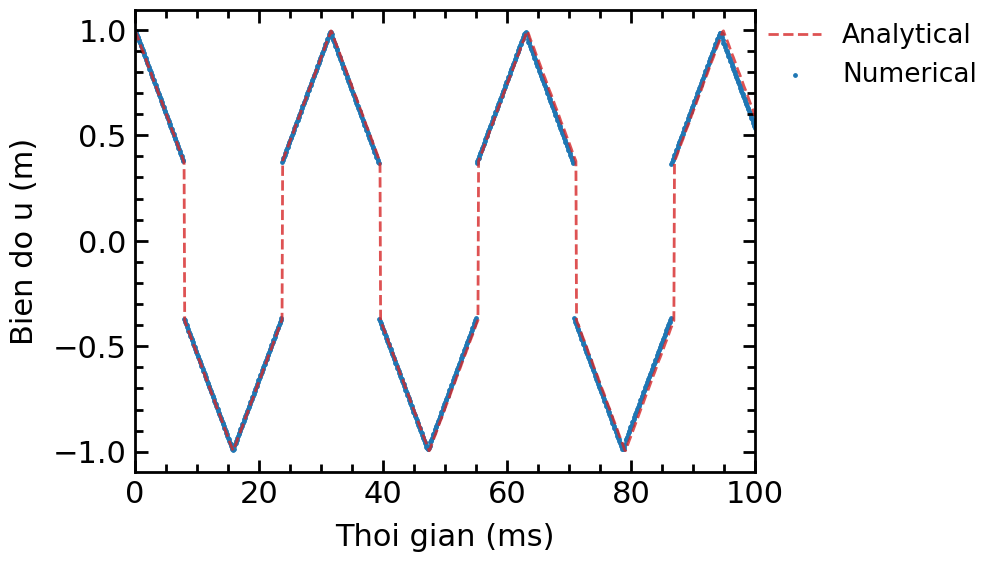

In [113]:
t_peak, x_dinh_song_num, u_dinh_song_num, x_dinh_song_anal, u_dinh_song_anal = np.loadtxt(filename_vantoc, comments='#', unpack=True)

plt.figure(figsize=(8, 6))

t_peak  = t_peak *1000
plt.xlabel('Thoi gian (ms)')
plt.ylabel('Bien do u (m)')

plt.xlim(0,100)

plt.plot(t_peak, u_dinh_song_anal, label='Analytical', linestyle='--',  color = "C1", linewidth=2, alpha =0.8)
plt.scatter(t_peak, u_dinh_song_num, label='Numerical', color = "C0", s=6)

plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', borderaxespad=0.1)
plt.savefig("dinh_song_full_sosanh.pdf", bbox_inches='tight')
plt.show()

Van toc song la c = -63.3900 m/s


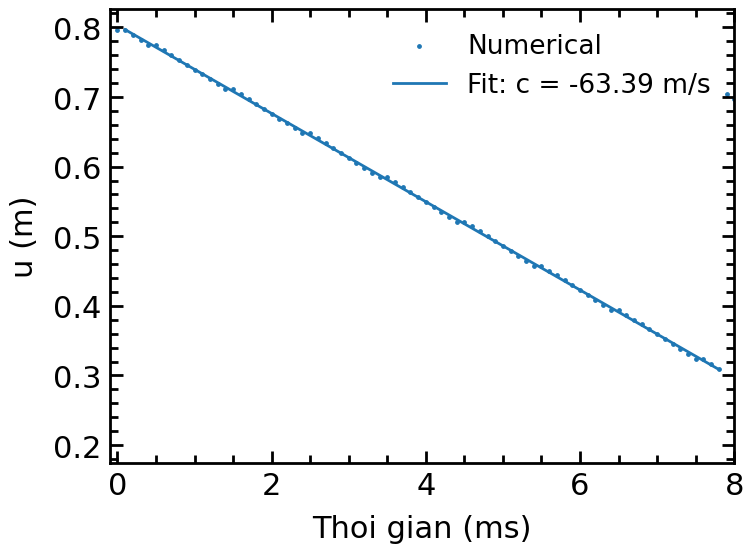

In [112]:
t_peak, x_dinh_song_num, u_dinh_song_num, x_dinh_song_anal, u_dinh_song_anal = np.loadtxt(filename_vantoc, comments='#', unpack=True)

t_peak_ms = t_peak * 1000

mask_fit = (t_peak_ms >= 0.1) & (t_peak_ms <= 7.8)

t_fit_data = t_peak[mask_fit] 
x_fit_data = x_dinh_song_num[mask_fit]

coef  = np.polyfit(t_fit_data, x_fit_data, deg=1)
c_num = coef[0]
print(f"Van toc song la c = {c_num:.4f} m/s")

t_line = np.linspace(t_fit_data.min(), t_fit_data.max(), 200)
x_line = np.polyval(coef, t_line)

plt.figure(figsize=(8, 6))
plt.scatter(t_peak_ms, x_dinh_song_num, label='Numerical', color="C0", s=6)
plt.plot(t_line * 1000, x_line, color="C0", label=f'Fit: c = {c_num:.2f} m/s')

plt.xlabel('Thoi gian (ms)')
plt.ylabel('u (m)')
plt.xlim(-0.1, 8)
plt.legend()
plt.tight_layout()
plt.savefig("hoi_quy_van_toc.pdf", bbox_inches='tight')
plt.show()